<a href="https://colab.research.google.com/github/manasa7695-dotcom/ML-projects/blob/main/CNN_TASK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1: Data Loading & Understanding


In [ ]:
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout

In [ ]:
from tensorflow.keras import layers

In [ ]:
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
plt.style.use('fivethirtyeight')

 Load the image dataset using TensorFlow/Keras.  


In [ ]:
from keras.datasets import fashion_mnist

In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

 Display dataset shape and sample images.  


In [ ]:
type(x_train)

numpy.ndarray

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
x_train[100]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0,  18,
        107, 119, 103,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  99, 155,
        113,  61, 118, 173, 117,   0,   0,   3,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   1,   0, 110, 136,   0,
          0,   0,   0,   0, 167, 159,   0,   0,   2,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   1,   0,   6,   0,  72, 147,   0,   0,
          5,   0,   2,   0,   0, 174, 118,   0,   5,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   1,   5,   0,   0, 174,   4,   0,   4,
          0,   0,   0,   0,   0,   0, 204,  44,   0,   4,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   8,   0, 125, 128,   0,   9,   0,
          0,   0,   0,   0,   2,   0, 107, 152,   0,   6,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 184,   9,   0,   4,   0,
          0,   0,   0,   0,   2,   0,   0, 190,   0,   0,   2,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   2,   0,  73, 158,   0,   0,   0,   0,
          1,   0,   0,   0,   0,   4,   0, 157,  79,   0,   3,   1,   0,
          0,   0],
       [  0,   0,   2,   5,   1,   0,   0, 157,  98,   0,   2,   0,   0,
          1,   0,   0,   0,   0,   5,   0, 121, 145,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 231,  84,   0,   2,   1,   1,
          0,   0,   0,   0,   0,   1,   0,  92, 223,  16,   0,   7,   4,
          1,   0],
       [  0,   0,   0,   0,   0,   0,  38, 183,  81,   0,   0,   0,   2,
          2,   1,   2,   1,   0,   1,   0, 120, 226,  57,   0,   0,   0,
          0,   0],
       [  0,   0, 173, 216, 193, 213, 183, 164, 167,  98,  16,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 107, 141, 111,  91,  90, 108,
         50,   0],
       [  0,   0, 185, 221, 217, 210, 202, 222, 200, 206, 202, 204, 109,
         27,  12,  17,  61, 136, 180, 221, 202, 225, 208, 214, 223, 240,
        162,   0],
       [  0,   0, 183, 220, 205, 200, 193, 184, 189, 182, 173, 194, 215,
        216, 205, 207, 207, 195, 185, 194, 194, 203, 212, 183, 193, 211,
        153,   0],
       [  0,   0, 190, 233, 203, 206, 214, 216, 195, 183, 176, 159, 175,
        189, 202, 195, 186, 186, 182, 186, 195, 209, 235, 203, 202, 215,
        136,   0],
       [  0,   0, 180, 228, 201, 202, 188, 183, 178, 192, 186, 181, 181,
        177, 204, 217, 175, 179, 184, 176, 166, 169, 175, 185, 152, 203,
        107,   0],
       [  0,   0, 167, 235, 200, 207, 207, 209, 207, 203, 198, 189, 182,
        178, 186, 189, 178, 192, 197, 195, 192, 185, 184, 205, 187, 255,
         61,   0],
       [  0,   0, 152, 250, 208, 214, 209, 202, 200, 202, 205, 204, 200,
        192, 198, 204, 195, 205, 206, 198, 199, 203, 214, 207, 179, 249,
         55,   0],
       [  0,   0, 126, 255, 211, 215, 210, 206, 203, 203, 203, 206, 204,
        199, 206, 207, 200, 206, 201, 199, 202, 208, 215, 195, 174, 211,
         15,   0],
       [  0,   0, 107, 255, 212, 211, 210, 211, 208, 206, 206, 207, 208,
        208, 217, 214, 205, 206, 204, 208, 211, 211, 220, 197, 182, 225,
          0,   0],
       [  0,   0,  63, 232, 211, 216, 212, 214, 212, 212, 214, 212, 211,
        212, 223, 219, 210, 214, 213, 212, 211, 209, 217, 208, 168, 190,
          0,   0],
       [  0,   0,  14, 255, 218, 221, 215, 218, 218, 217, 215, 213, 211,
        215, 228, 220, 216, 222, 217, 217, 216, 218, 212, 213, 189, 143,
          0,   0],
       [  0,   0,   0, 230, 227, 214, 217, 218, 216, 217, 217, 214, 216,
        222, 226, 218, 218, 220, 219, 218, 217, 218, 217, 215, 216, 113,
          0,   0],
       [  0,   0,   0, 177, 233, 216, 223, 222, 213, 213, 215, 212, 220,
        226, 221, 220, 221, 218, 222, 220, 220, 221, 217, 212, 219,  52,
          0,   0],
       [  0,   0,   0,  10, 223, 222, 22

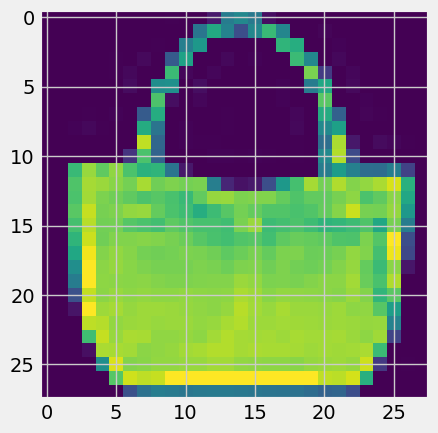

In [ ]:
img0=plt.imshow(x_train[100])

In [ ]:
lab1=y_train[100]
print(lab1)

8


Check the number of classes and images per class.


In [ ]:
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

Number of classes: 10


In [ ]:
unique, counts = np.unique(y_train, return_counts=True)

In [ ]:
classification=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [ ]:
print("\nImages per class:")
for cls, count in zip(unique, counts):
    print(f" {classification[cls]}: {count} images")


Images per class:
 T-shirt/top: 6000 images
 Trouser: 6000 images
 Pullover: 6000 images
 Dress: 6000 images
 Coat: 6000 images
 Sandal: 6000 images
 Shirt: 6000 images
 Sneaker: 6000 images
 Bag: 6000 images
 Ankle boot: 6000 images


In [ ]:
print('image class is',classification[y_train[100]])

image class is Bag


2: Data Preprocessing


Normalize pixel values (0–255 → 0–1).  


In [ ]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [ ]:
x_train=x_train/255
x_test=x_test/255

Encode class labels if necessary.  


In [ ]:
y_train_cat=to_categorical(y_train)
y_test_cat=to_categorical(y_test)

In [ ]:
y_train_cat[10]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

3: CNN Architecture Design


1. Convolution Layer(s)  
2. ReLU Activation Function  
3. Max Pooling Layer(s)  
4. Flatten Layer  
5. Fully Connected (Dense) Layer  
6. Output Layer (Softmax)  

In [ ]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Flatten())
model.add(Dense(1000,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(500,activation='softmax'))
model.add(Dropout(0.5))
model.add(Dense(250,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1000)           │       577,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         2,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,261,004 (4.81 MB)

 Trainable params: 1,261,004 (4.81 MB)

 Non-trainable params: 0 (0.00 B)

The Fashion MNIST dataset is already pre-split into training and testing sets when loaded using `fashion_mnist.load_data()`.

In [ ]:
print(f'Shape of training images (x_train): {x_train.shape}')
print(f'Shape of training labels (y_train): {y_train.shape}')
print(f'Shape of testing images (x_test): {x_test.shape}')
print(f'Shape of testing labels (y_test): {y_test.shape}')

Shape of training images (x_train): (60000, 28, 28, 1)
Shape of training labels (y_train): (60000,)
Shape of testing images (x_test): (10000, 28, 28, 1)
Shape of testing labels (y_test): (10000,)


5: Model Building & Training


1. Optimizer: Adam  
2. Loss Function: Categorical/Sparse Categorical Crossentropy  
3. Metric: Accuracy

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

 Train the model for a suitable number of epochs.  


In [ ]:
tr=model.fit(x_train,y_train_cat,epochs=20,batch_size=250,validation_split=0.2)
model.evaluate(x_test,y_test_cat)

Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 70s 341ms/step - accuracy: 0.3883 - loss: 1.6885 - val_accuracy: 0.7174 - val_loss: 0.8298
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 71s 288ms/step - accuracy: 0.6784 - loss: 0.8752 - val_accuracy: 0.7837 - val_loss: 0.5611
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 56s 290ms/step - accuracy: 0.7797 - loss: 0.6041 - val_accuracy: 0.8305 - val_loss: 0.4296
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 83s 297ms/step - accuracy: 0.8312 - loss: 0.4690 - val_accuracy: 0.8616 - val_loss: 0.3750
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 88s 330ms/step - accuracy: 0.8635 - loss: 0.3905 - val_accuracy: 0.8828 - val_loss: 0.3304
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 75s 392ms/step - accuracy: 0.8852 - loss: 0.3339 - val_accuracy: 0.8906 - val_loss: 0.3045
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 65s 302ms/step - accuracy: 0.8950 - loss: 0.2998 - val_accuracy: 0.8913 - val_loss: 0.3002
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 53s 278ms/step - accuracy: 0.9019 - loss: 0

[0.2826124131679535, 0.9090999960899353]

6: Model Evaluation


1. Accuracy Score
2. Loss Value  




In [ ]:
loss, accuracy = model.evaluate(x_test, y_test_cat)
print("Test Loss  :", loss)
print("Test Acc   :", accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9091 - loss: 0.2826
Test Loss  : 0.2826124131679535
Test Acc   : 0.9090999960899353


 Plot Training vs Validation Accuracy


Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 55s 285ms/step - accuracy: 0.9523 - loss: 0.1336 - val_accuracy: 0.9166 - val_loss: 0.2649
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 83s 288ms/step - accuracy: 0.9556 - loss: 0.1236 - val_accuracy: 0.9148 - val_loss: 0.2756
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 55s 287ms/step - accuracy: 0.9568 - loss: 0.1200 - val_accuracy: 0.9156 - val_loss: 0.2829
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 54s 283ms/step - accuracy: 0.9581 - loss: 0.1164 - val_accuracy: 0.9173 - val_loss: 0.2788
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 55s 287ms/step - accuracy: 0.9620 - loss: 0.1068 - val_accuracy: 0.9150 - val_loss: 0.2852
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 82s 290ms/step - accuracy: 0.9643 - loss: 0.1018 - val_accuracy: 0.9163 - val_loss: 0.2991
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 54s 279ms/step - accuracy: 0.9658 - loss: 0.0965 - val_accuracy: 0.9175 - val_loss: 0.2975
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 82s 277ms/step - accuracy: 0.9674 - loss: 0

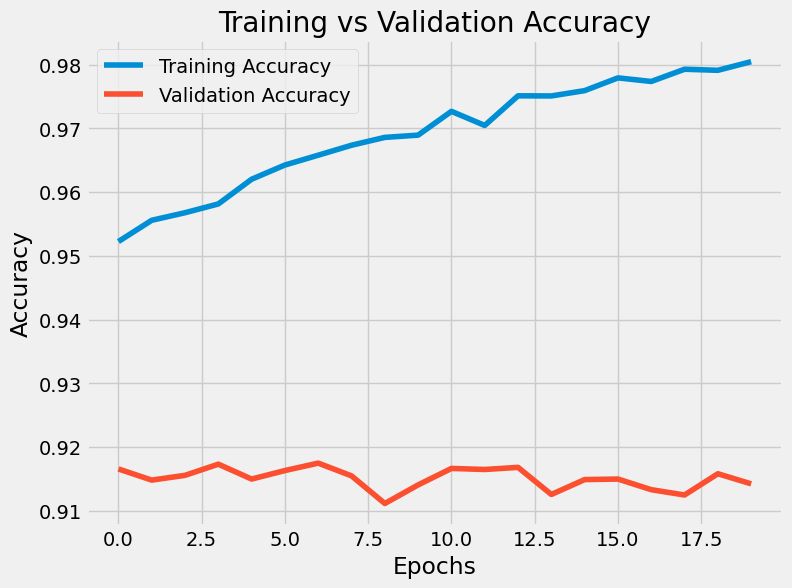

In [ ]:
# Plot Training vs Validation Accuracy
history = model.fit(x_train, y_train_cat,epochs=20,batch_size=250,validation_split=0.2)
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

Training Loss vs Validation Loss  


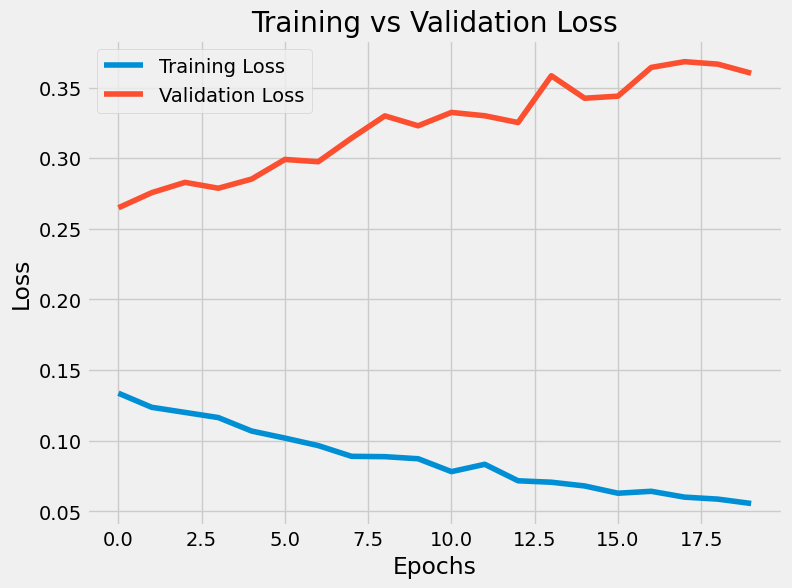

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

7: Prediction on New Images


 Select one or more test images.  


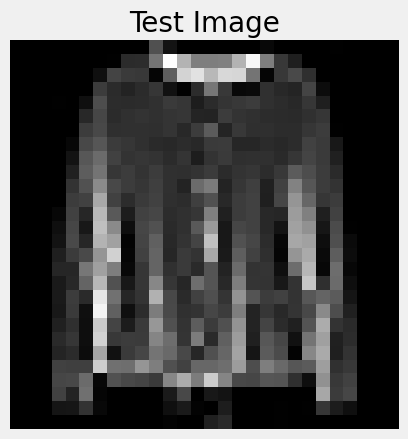

In [ ]:
index = 25

plt.imshow(x_test[index,:,:,0], cmap='gray')
plt.title("Test Image")
plt.axis('off')
plt.show()

Predicting the image class using the trained CNN model.  


In [ ]:
prediction = model.predict(x_test[index].reshape(1,28,28,1),verbose=0)
predicted_class = np.argmax(prediction)

 Compare predicted labels with actual labels.  


In [ ]:
print("Actual Label    :", classification[y_test[index]])
print("Predicted Label :", classification[predicted_class])

Actual Label    : Coat
Predicted Label : Pullover


8: Hyperparameter Tuning


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout

def build_model(filters, kernel_size):
    model = Sequential()
    model.add(Conv2D(filters, kernel_size, activation='relu', input_shape=(28,28,1)))
    model.add(MaxPooling2D(2,2))
    model.add(Conv2D(filters*2, kernel_size, activation='relu'))
    model.add(MaxPooling2D(2,2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
    return model

# Model 1
model1 = build_model(32, (3,3))
M1=model1.fit(x_train, y_train_cat, epochs=10, validation_data=(x_test, y_test_cat))
# Model 2
model2 = build_model(64, (3,3))
M2=model2.fit(x_train, y_train_cat, epochs=10, validation_data=(x_test, y_test_cat))
# Model 3
model3 = build_model(32, (5,5))
M3=model3.fit(x_train, y_train_cat, epochs=10, validation_data=(x_test, y_test_cat))

print("Model 1 Accuracy:", M1.history['val_accuracy'][-1])
print("Model 2 Accuracy:", M2.history['val_accuracy'][-1])
print("Model 3 Accuracy:", M3.history['val_accuracy'][-1])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - accuracy: 0.8362 - loss: 0.4510 - val_accuracy: 0.8752 - val_loss: 0.3505
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.8909 - loss: 0.2997 - val_accuracy: 0.8814 - val_loss: 0.3124
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9063 - loss: 0.2538 - val_accuracy: 0.8956 - val_loss: 0.2871
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9166 - loss: 0.2234 - val_accuracy: 0.9068 - val_loss: 0.2632
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9263 - loss: 0.1948 - val_accuracy: 0.9004 - val_loss: 0.2807
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9353 - loss: 0.1732 - val_accuracy: 0.9056 - val_loss: 0.2603
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9410 - loss: 0.1559 - val_accuracy: 0.9083 - val_loss: 0.2566
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.9487 -

9: Feature Map Visualization


 Visualize feature maps generated by convolution layers.  


In [ ]:
from keras.models import Model
import matplotlib.pyplot as plt
feature_model = Model(inputs=model.inputs,outputs=model.layers[0].output)
img = x_test[4].reshape(1,28,28,1)
feature_maps = feature_model.predict(img)
print(feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
(1, 26, 26, 32)


Observe how CNN extracts edges, textures, and patterns from images.  

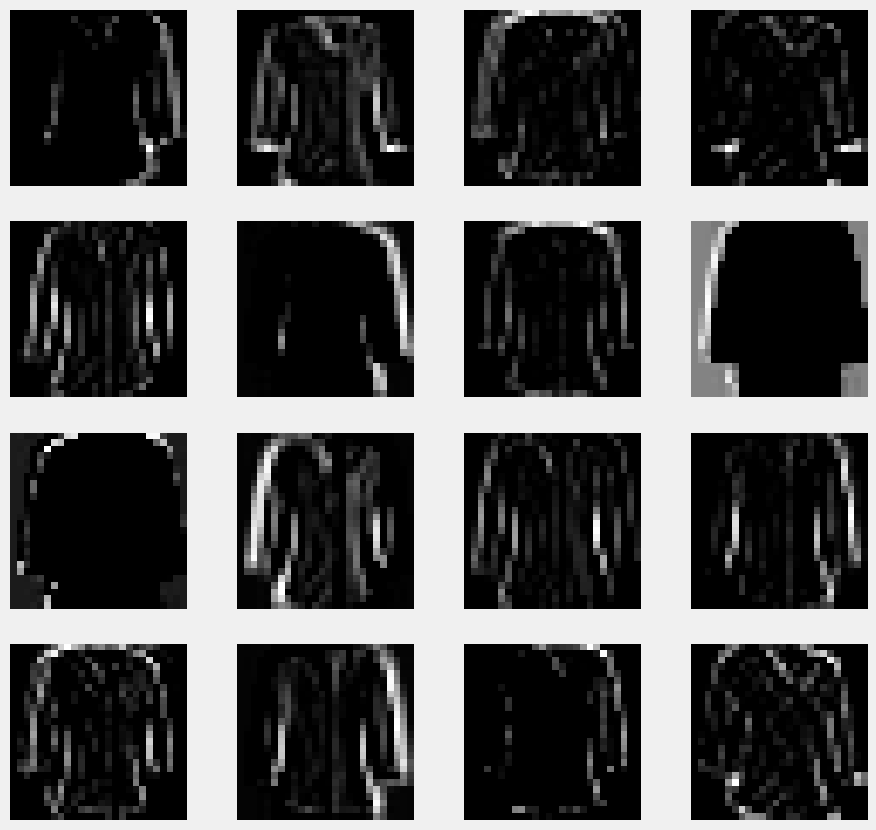

In [ ]:
plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='gray')
    plt.axis('off')
plt.show()